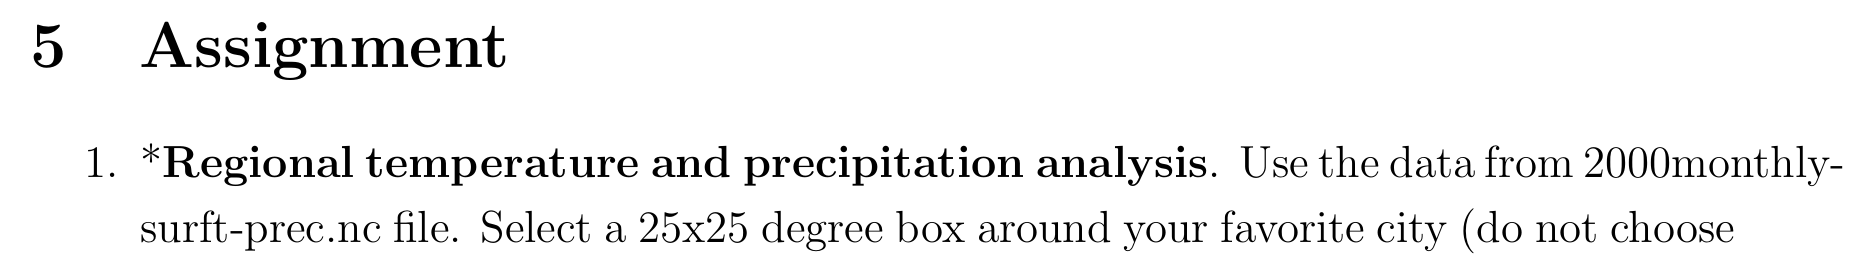
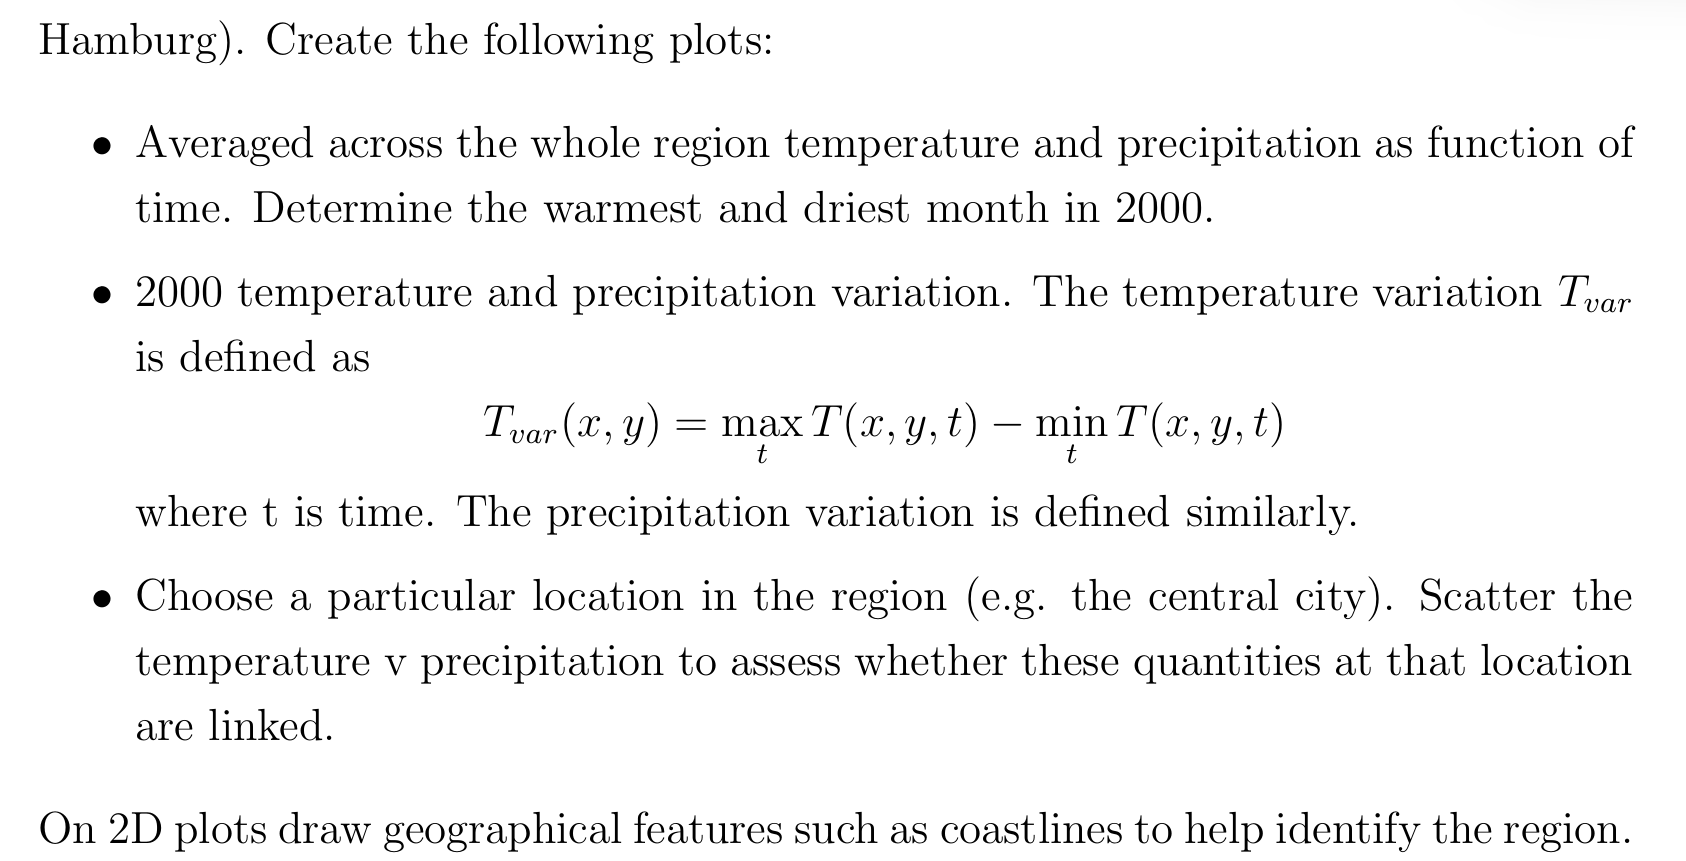

In [1]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import xarray as xr

path = Path('2000monthly-surft-prec.nc')

ds = xr.open_dataset(path, engine='scipy')
ds

<xarray.Dataset> Size: 2MB
Dimensions:    (longitude: 144, latitude: 73, time: 12)
Coordinates:
  * longitude  (longitude) float32 576B 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * latitude   (latitude) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * time       (time) datetime64[ns] 96B 2000-01-01 2000-02-01 ... 2000-12-01
Data variables:
    lsp        (time, latitude, longitude) float64 1MB ...
    t2m        (time, latitude, longitude) float64 1MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2021-05-02 21:46:23 GMT by grib_to_netcdf-2.21.0: grib_to_n...

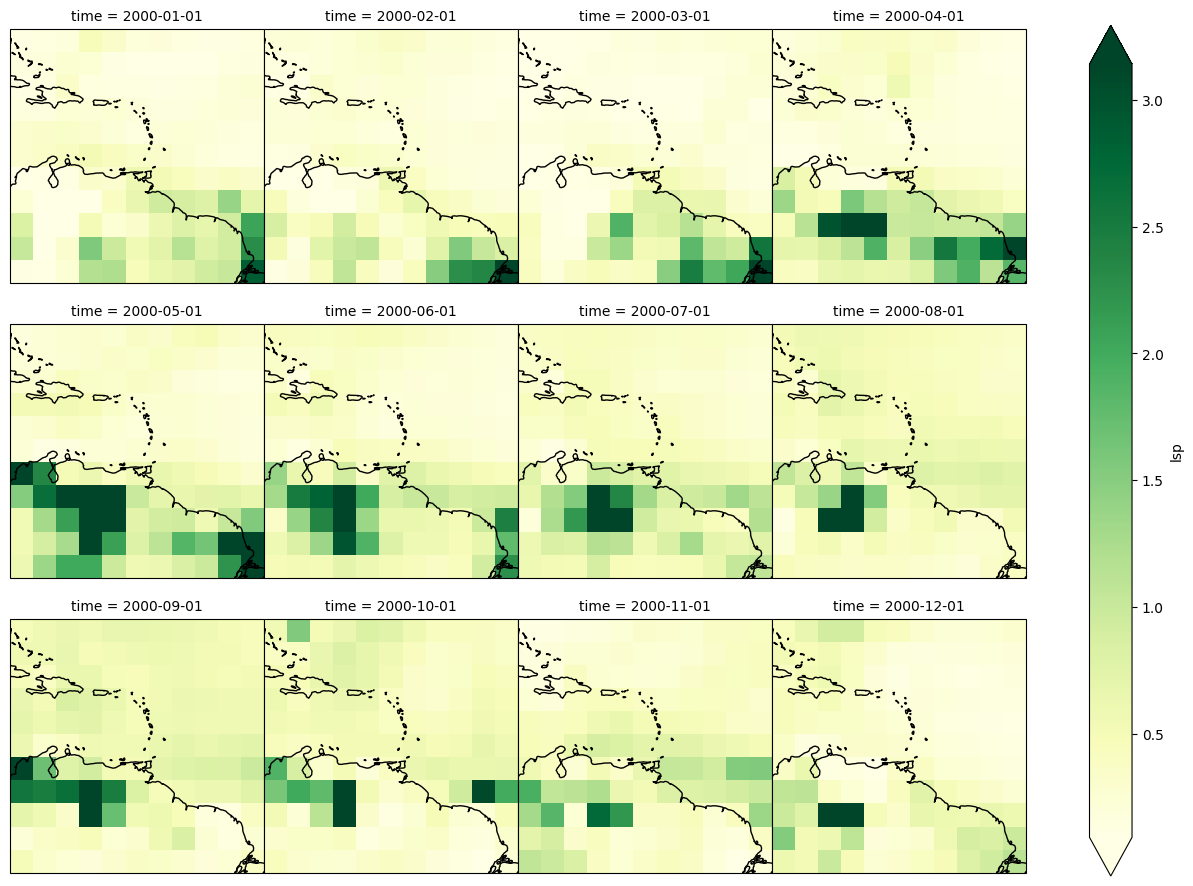

In [2]:
# Coordinates of Sauteurs, Grenada.
lon_center, lat_center = 298.3, 12.3
lon = ds['longitude'].sel(longitude=lon_center, method='nearest')
lat = ds['latitude'].sel(latitude=lat_center, method='nearest')

# Create 25 x 25 degree box around city.
longitudes: slice = slice(lon-12.5, lon+12.5)
latitudes: slice = slice(lat+12.5, lat-12.5)

# Select region from dataset.
rain = ds['lsp'].sel(latitude=latitudes, longitude=longitudes) * 1000

# Large-scale precipitation.
ax = rain.plot(x="longitude", y="latitude", col='time', col_wrap=4, cmap='YlGn',
               subplot_kws={'projection': ccrs.PlateCarree()},
               transform=ccrs.PlateCarree(),
               robust=True)
ax.map(lambda: plt.gca().coastlines())

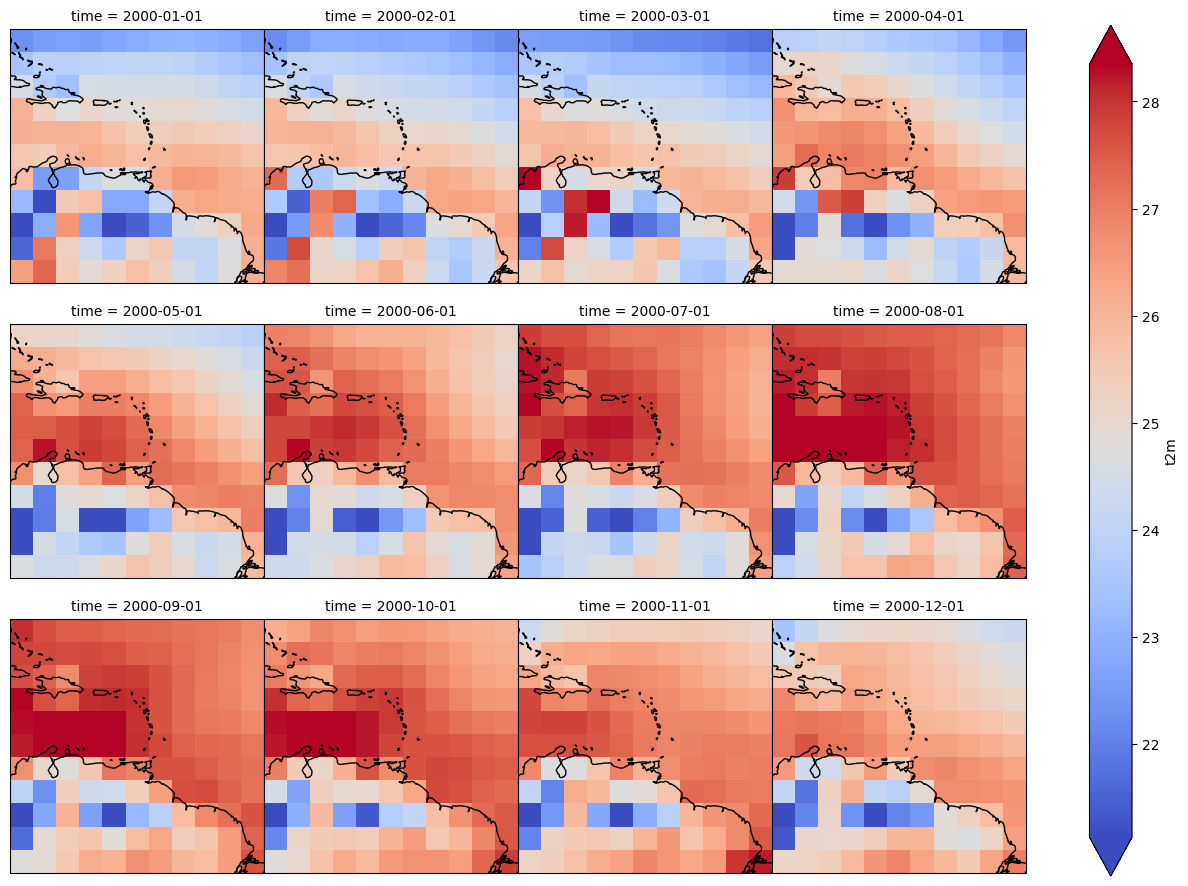

In [3]:
# Coordinates of Sauteurs, Grenada.
lon_center, lat_center = 298.3, 12.3
lon = ds['longitude'].sel(longitude=lon_center, method='nearest')
lat = ds['latitude'].sel(latitude=lat_center, method='nearest')

# Create 25 x 25 degree box around city.
longitudes: slice = slice(lon-12.5, lon+12.5)
latitudes: slice = slice(lat+12.5, lat-12.5)

# Select region from dataset.
temps = ds['t2m'].sel(latitude=latitudes, longitude=longitudes) - 273.15

# Large-scale precipitation.
ax = temps.plot(x="longitude", y="latitude", col='time', col_wrap=4, cmap='coolwarm',
               subplot_kws={'projection': ccrs.PlateCarree()},
               transform=ccrs.PlateCarree(),
               robust=True)
ax.map(lambda: plt.gca().coastlines())

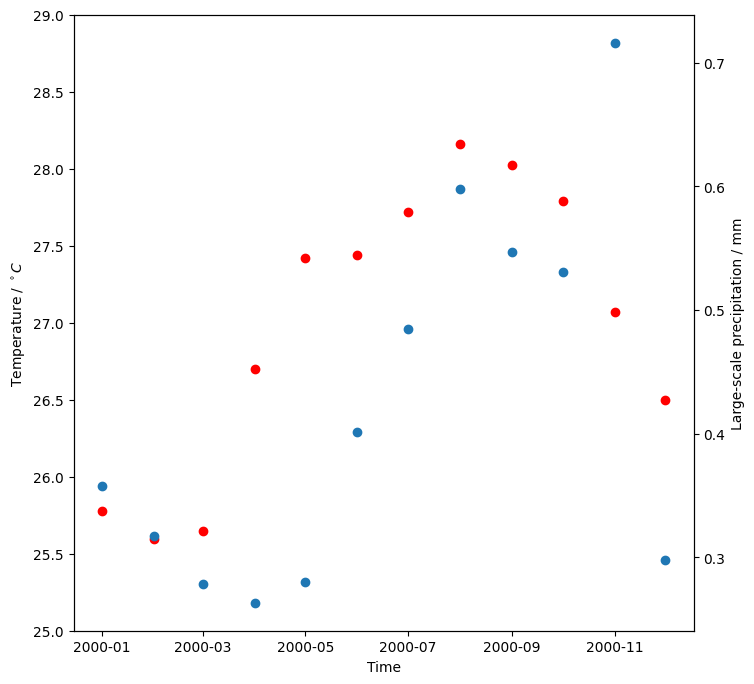

In [4]:
sauteurs_temps = ds['t2m'].sel(longitude=lon_center, latitude=lat_center, method='nearest') - 273.15

sauteurs_rain = ds['lsp'].sel(longitude=lon_center, latitude=lat_center, method='nearest') * 1_000

fig, ax1 = plt.subplots(figsize=(8, 8))
ax1.scatter(ds.time, sauteurs_temps, color='red')
ax1.set_ylabel(r"Temperature / $^\circ C$")
ax1.set_xlabel("Time")
ax1.set_ylim(25, 29)

ax2 = ax1.twinx()
ax2.scatter(ds.time, sauteurs_rain)
ax2.set_ylabel("Large-scale precipitation / mm")

plt.show()

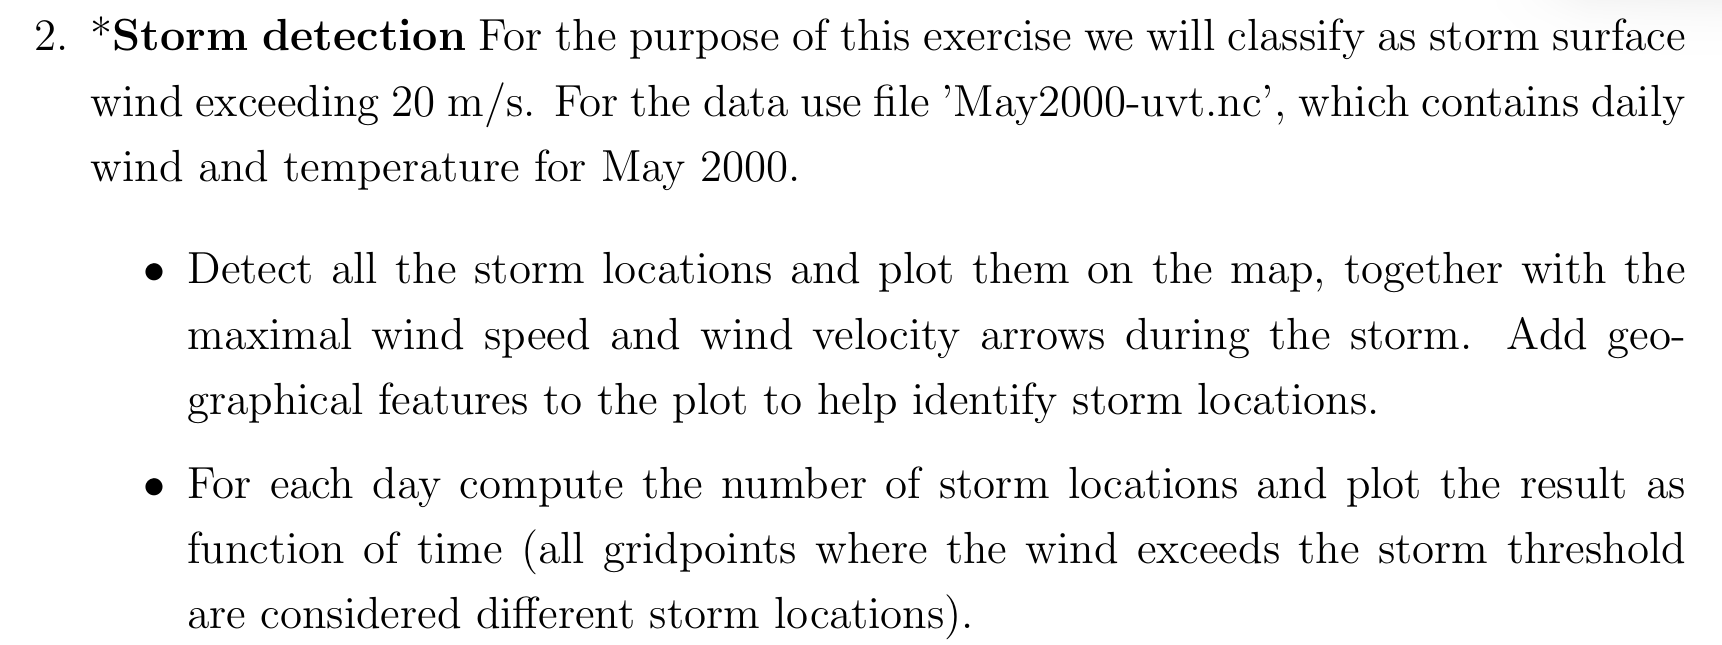

In [28]:
from pathlib import Path

import cartopy.crs as ccrs
import numpy as np
import xarray as xr

path = "May2000-uvt.nc"

ds = xr.open_dataset(path, engine='scipy')
ds

<xarray.Dataset> Size: 55MB
Dimensions:    (longitude: 144, latitude: 73, level: 7, time: 31)
Coordinates:
  * longitude  (longitude) float32 576B 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * latitude   (latitude) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * level      (level) int32 28B 1 10 100 250 500 775 1000
  * time       (time) datetime64[ns] 248B 2000-05-01T12:00:00 ... 2000-05-31T...
Data variables:
    t          (time, level, latitude, longitude) float64 18MB ...
    u          (time, level, latitude, longitude) float64 18MB ...
    v          (time, level, latitude, longitude) float64 18MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2021-05-02 22:12:40 GMT by grib_to_netcdf-2.21.0: grib_to_n...

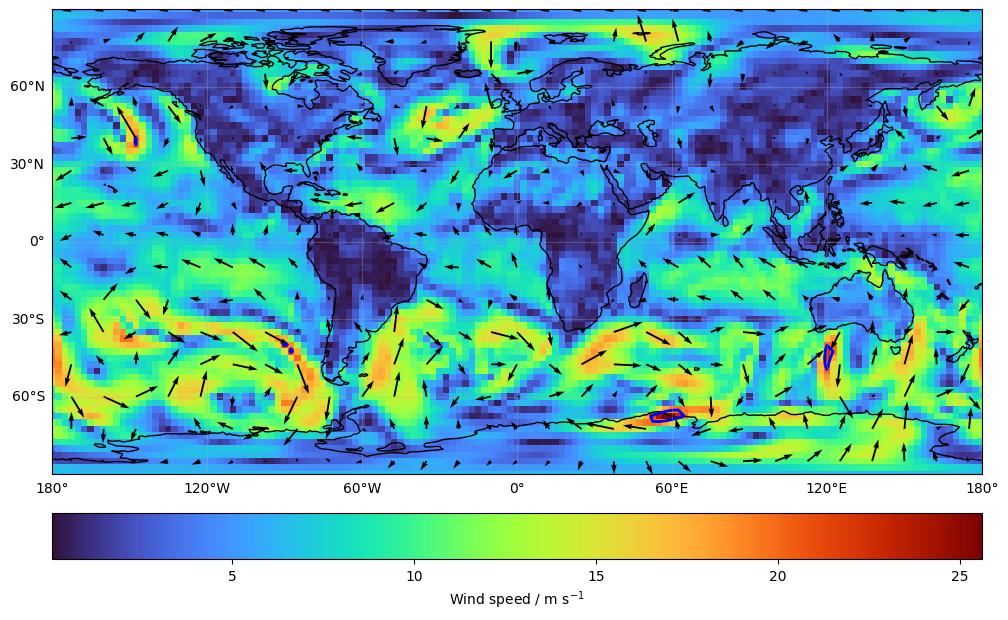

In [71]:
date = '2010-05-10'

# Select wind components.
u = ds['u'].sel(level=1000, time=date, method='nearest')
v = ds['v'].sel(level=1000, time=date, method='nearest')

# Lats and Lons.
x = ds['longitude']
y = ds['latitude']
X, Y = np.meshgrid(x, y)

# Compute wind speed.
wind_speed = np.sqrt(u**2 + v**2)

# Storms threshold.
storms = wind_speed.where(wind_speed >= 20)


# Plotting
fig, ax = plt.subplots(figsize=(12, 10),
                       subplot_kw=dict(projection=ccrs.PlateCarree()))

# Wind speed.
wind_plot = ax.pcolormesh(X, Y, wind_speed, cmap='turbo')

# Wind speed > 20 m/s.
ax.contour(
    X,
    Y,
    wind_speed,
    levels=[20],
    colors='blue',
    linewidths=2,
    transform=ccrs.PlateCarree()
)

ax.contourf(
    X,
    Y,
    storms,
    levels=[20, wind_speed.max()],
    hatches=['///'],
    colors='blue',
    transform=ccrs.PlateCarree()
)

# Wind vectors
skip = 5

ax.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    u.values[::skip, ::skip],
    v.values[::skip, ::skip],
    color='black',
    scale=500,
    width=0.002,
    transform=ccrs.PlateCarree()
)

ax.coastlines()

# Gridlines
gl = ax.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(wind_plot,
                    ax=ax,
                    label=r"Wind speed / m s$^{-1}$",
                    pad=0.05,
                    orientation='horizontal')

plt.show()

# wind_speed.plot(subplot_kws={'projection': ccrs.PlateCarree()},
#                 transform=ccrs.PlateCarree())
#
# ax = plt.gca()
# ax.quiver(X, Y, u, v, angles='uv', color='red')
# ax.coastlines()

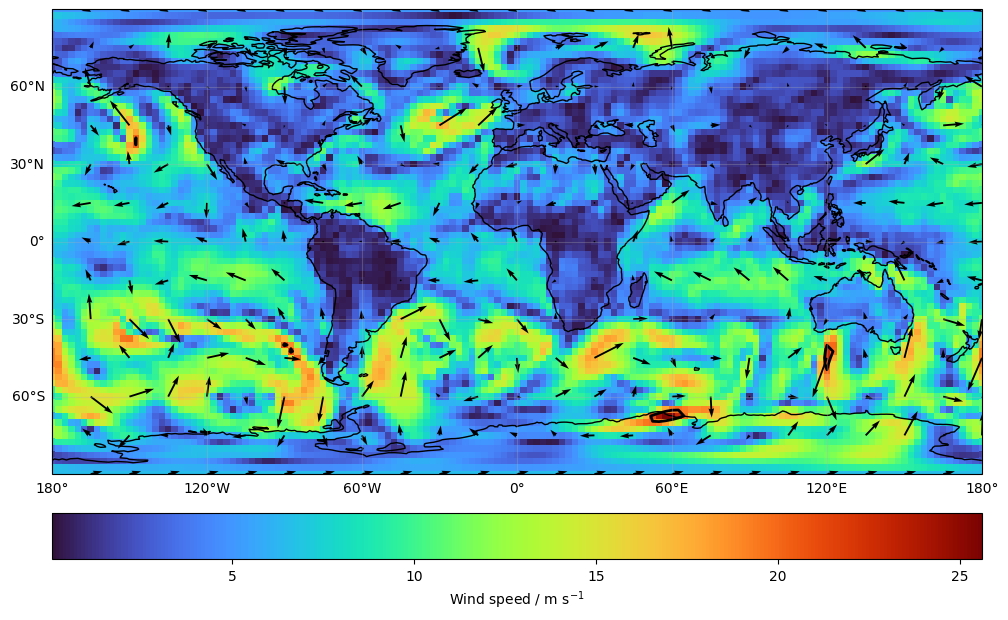

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Select date.
date = '2010-05-10'

# Select wind components.
u = ds['u'].sel(level=1000, time=date, method='nearest')
v = ds['v'].sel(level=1000, time=date, method='nearest')

# Coordinates.
lon = ds['longitude']
lat = ds['latitude']

X, Y = np.meshgrid(lon, lat)

# Wind speed.
wind_speed = np.sqrt(u**2 + v**2)

# Threshold mask.
high_winds = wind_speed.where(wind_speed >= 20)

# Figure.
fig, ax = plt.subplots(
    figsize=(12, 10),
    subplot_kw=dict(projection=ccrs.PlateCarree())
)

# Wind speed shading.
wind_plot = ax.pcolormesh(
    X,
    Y,
    wind_speed,
    cmap='turbo',
    shading='auto',
    transform=ccrs.PlateCarree()
)

# Highlight >20 m/s winds using contours.
ax.contour(
    X,
    Y,
    wind_speed,
    levels=[20],
    colors='black',
    linewidths=2,
    transform=ccrs.PlateCarree()
)

# Optional: hatch high wind regions.
ax.contourf(
    X,
    Y,
    high_winds,
    levels=[20, wind_speed.max()],
    hatches=['///'],
    colors='none',
    transform=ccrs.PlateCarree()
)

# Thin quiver vectors.
skip = 6

ax.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    u.values[::skip, ::skip],
    v.values[::skip, ::skip],
    color='black',
    scale=500,
    width=0.002,
    transform=ccrs.PlateCarree()
)

# Coastlines.
ax.coastlines()

# Gridlines.
gl = ax.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = False
gl.right_labels = False

# Colorbar.
cbar = fig.colorbar(
    wind_plot,
    ax=ax,
    orientation='horizontal',
    pad=0.05,
    label=r'Wind speed / m s$^{-1}$'
)

plt.show()

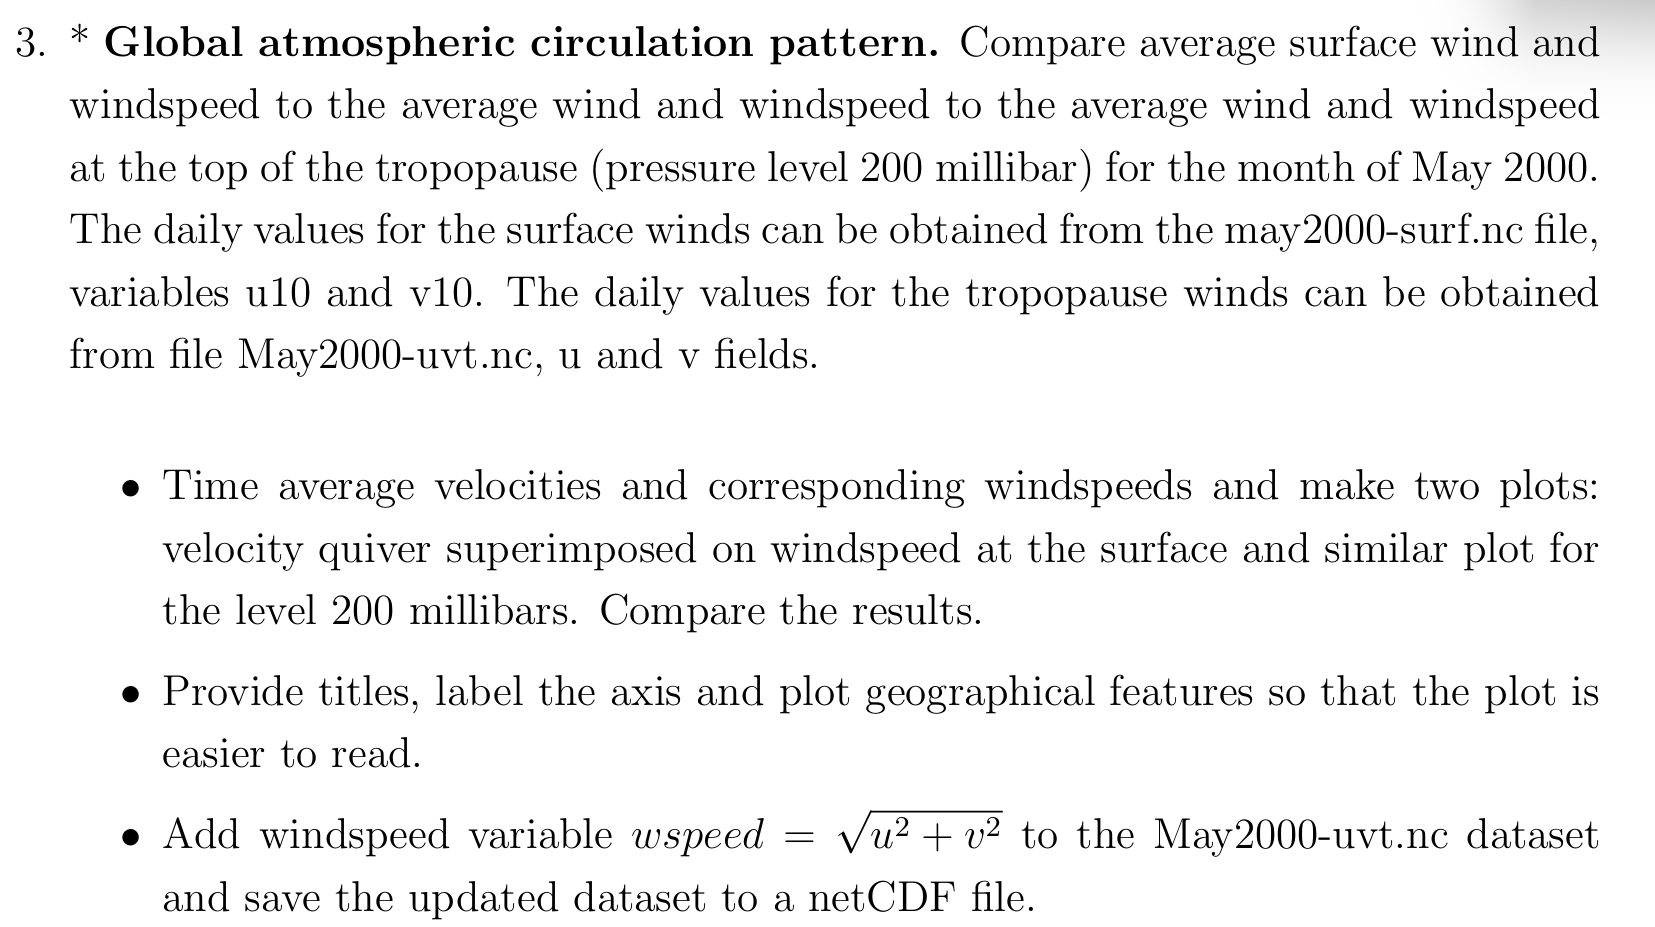
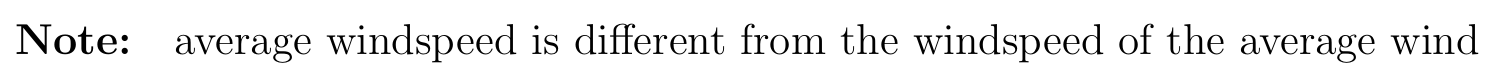
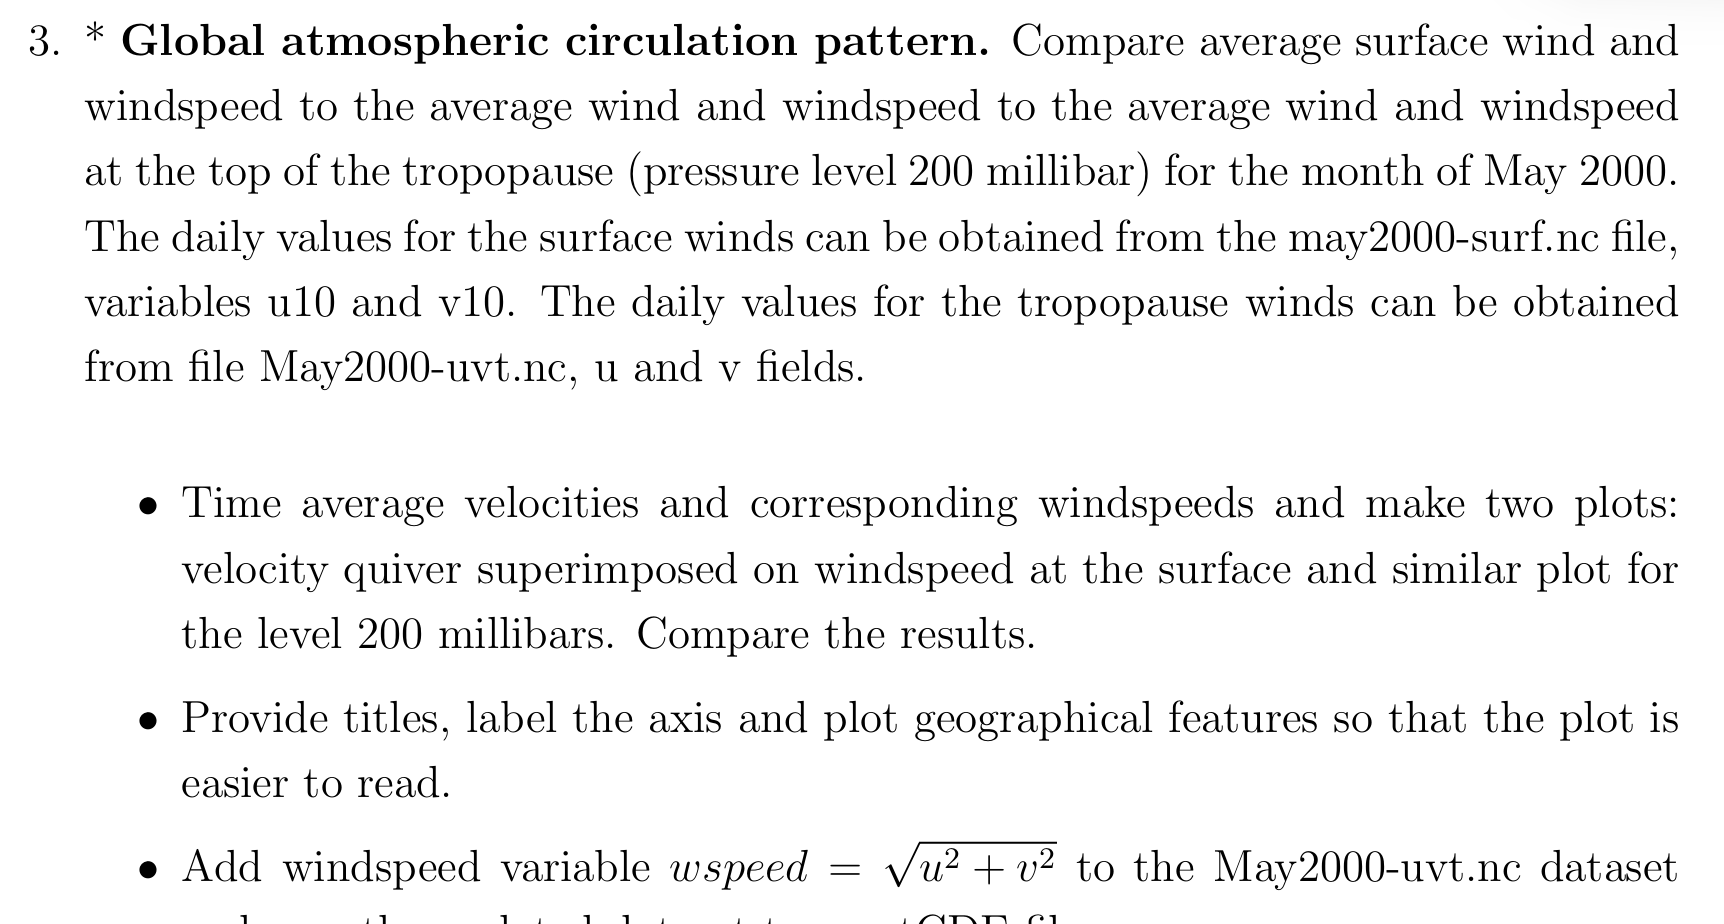
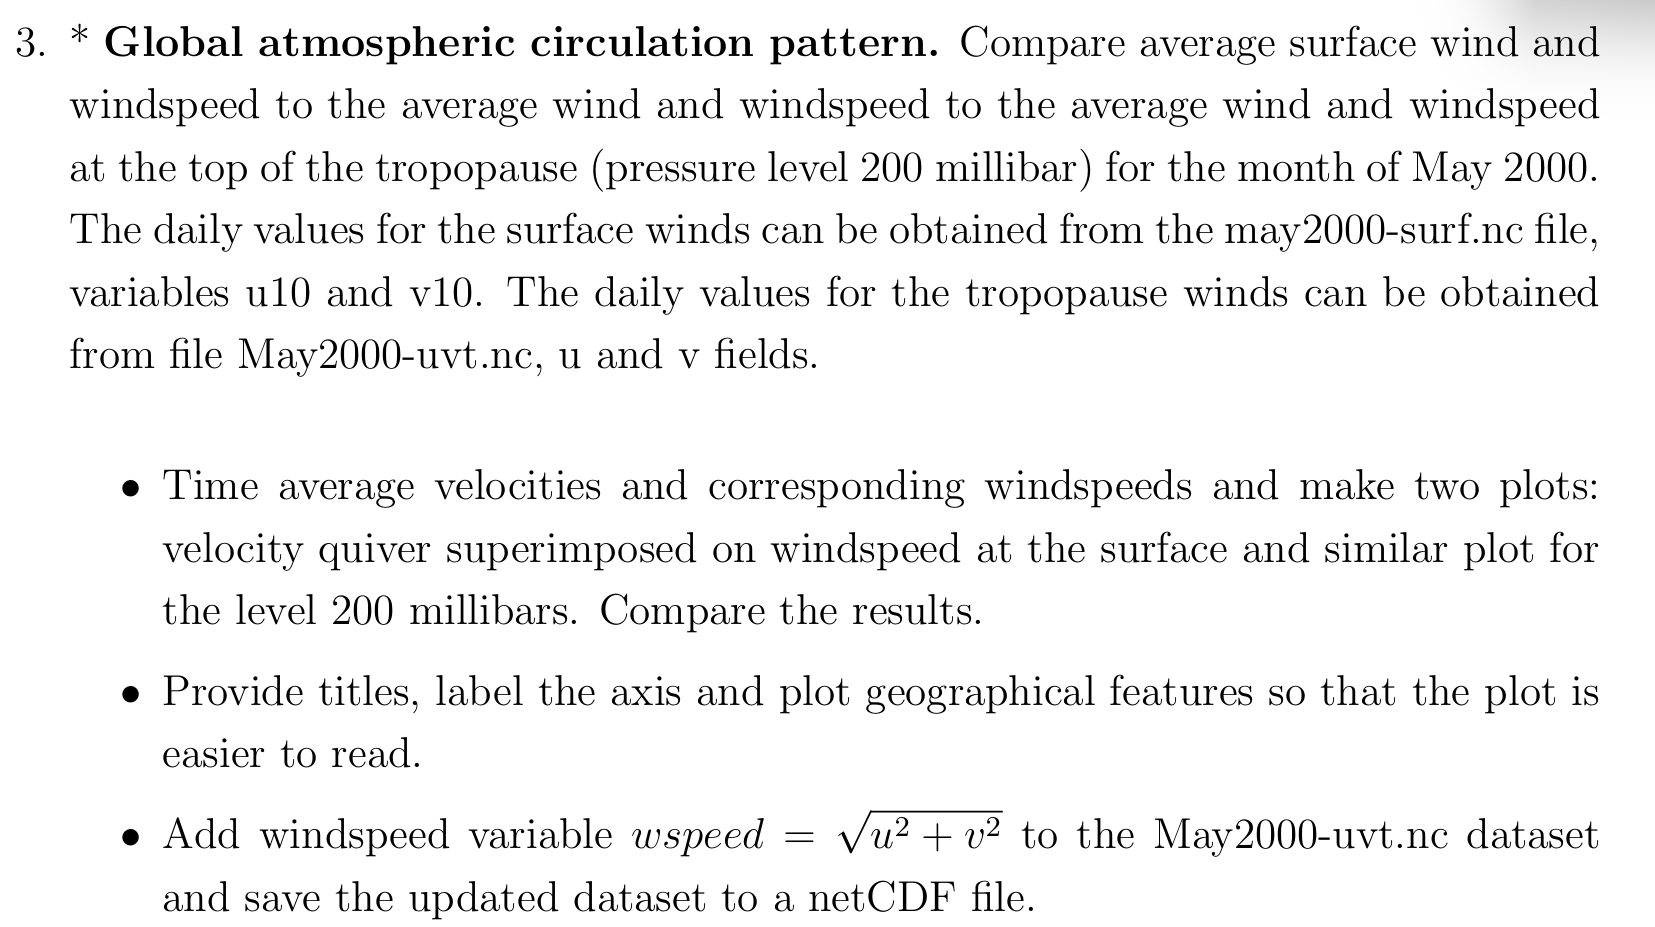

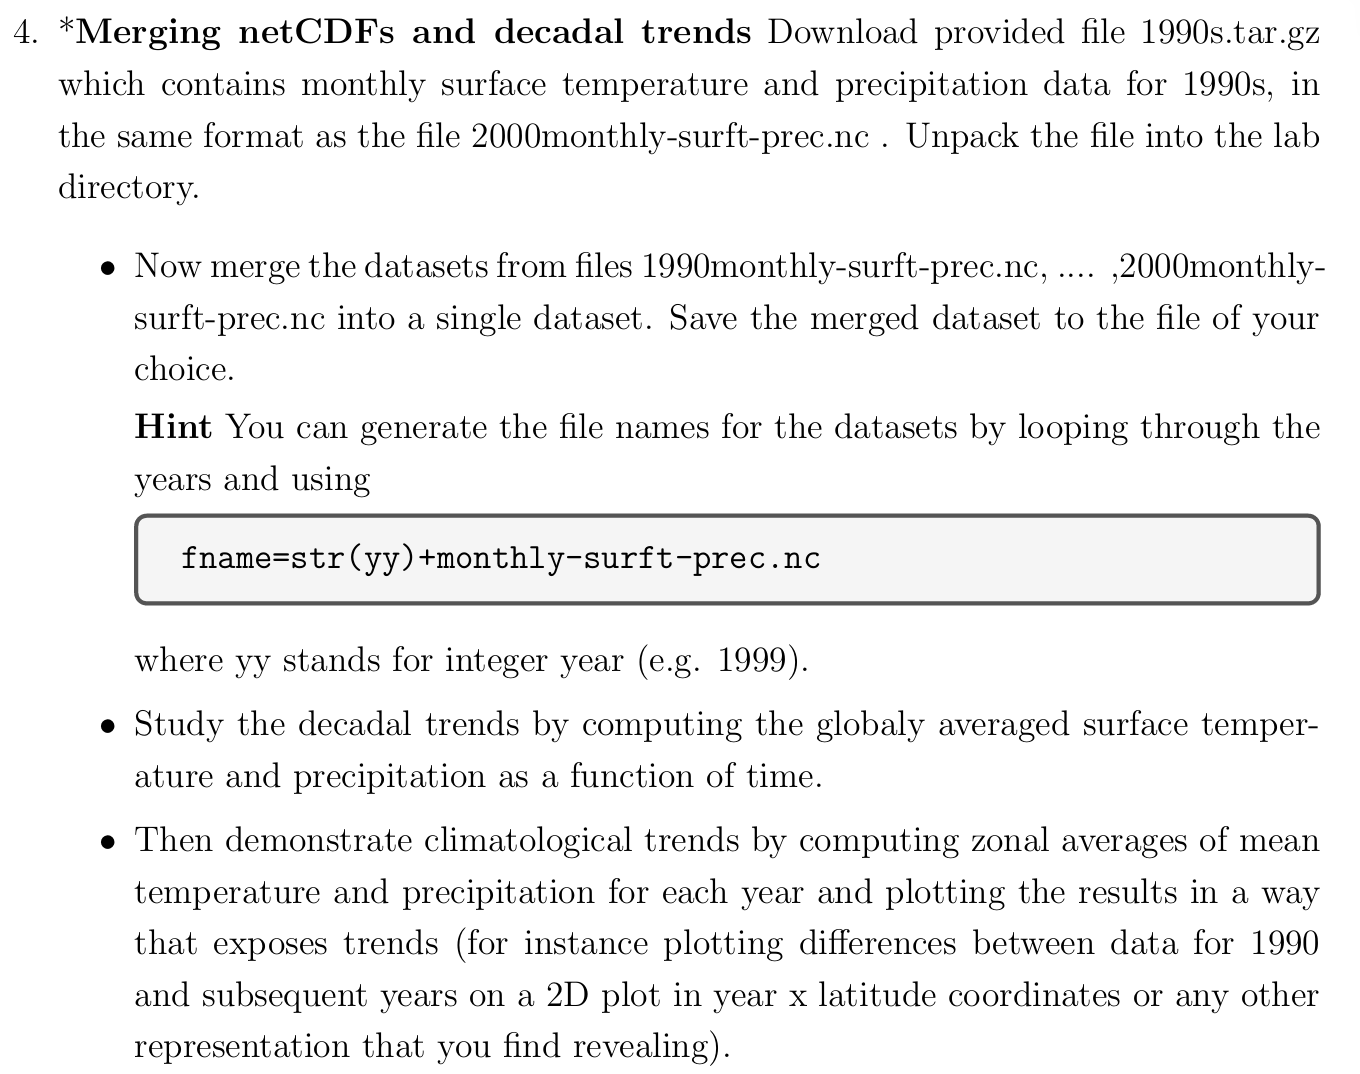

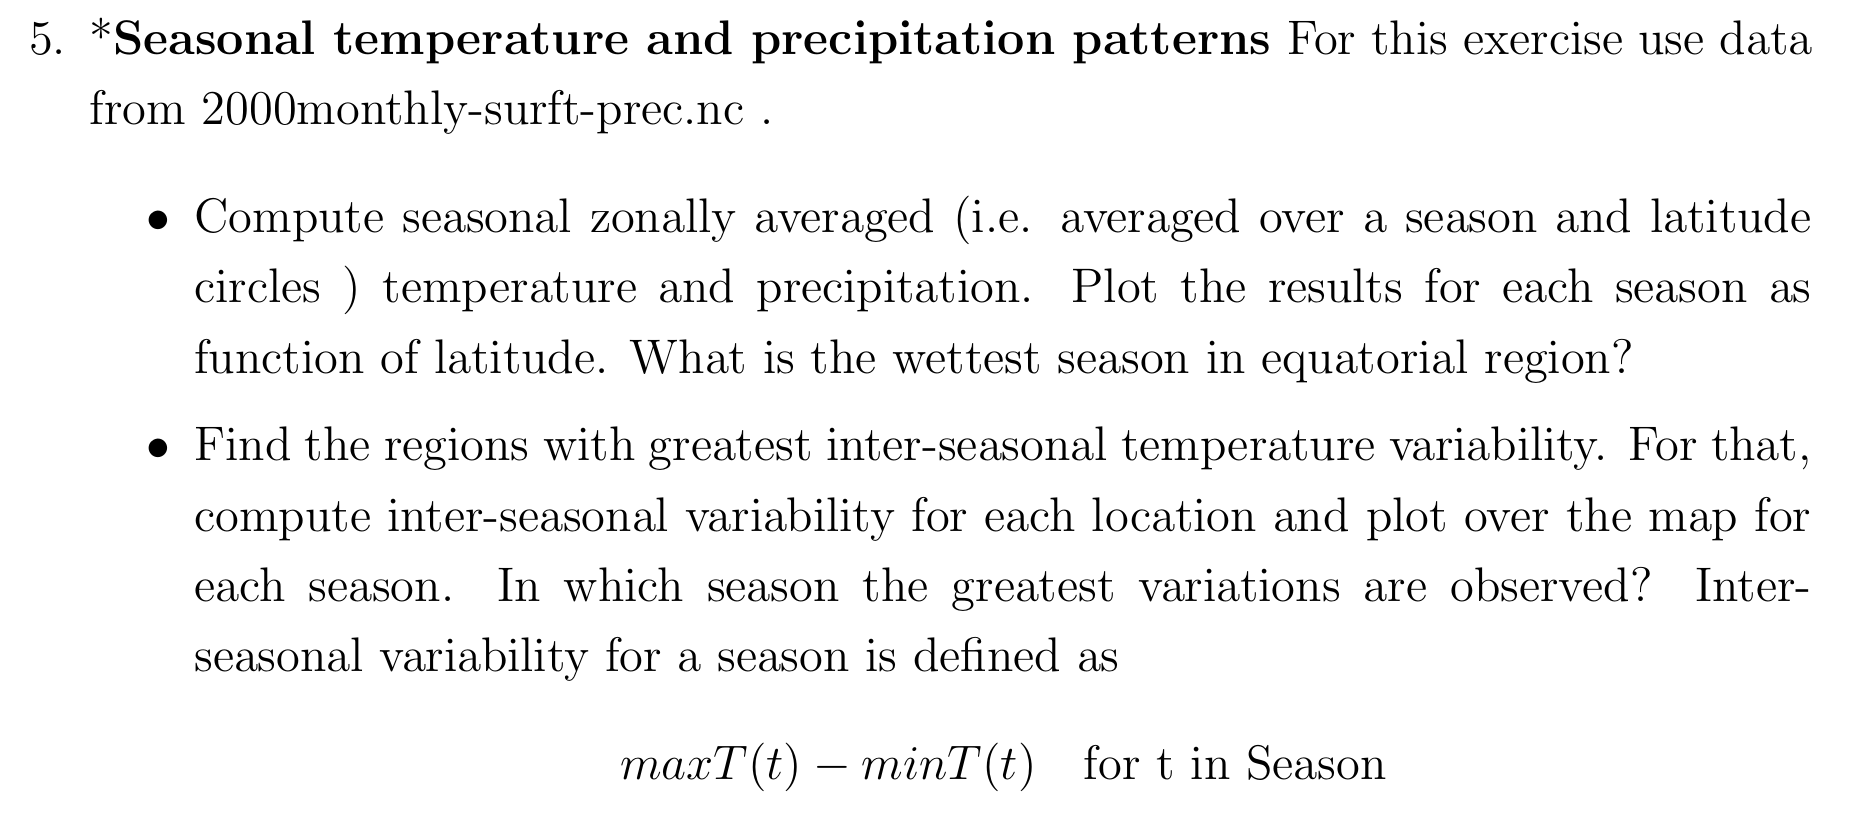

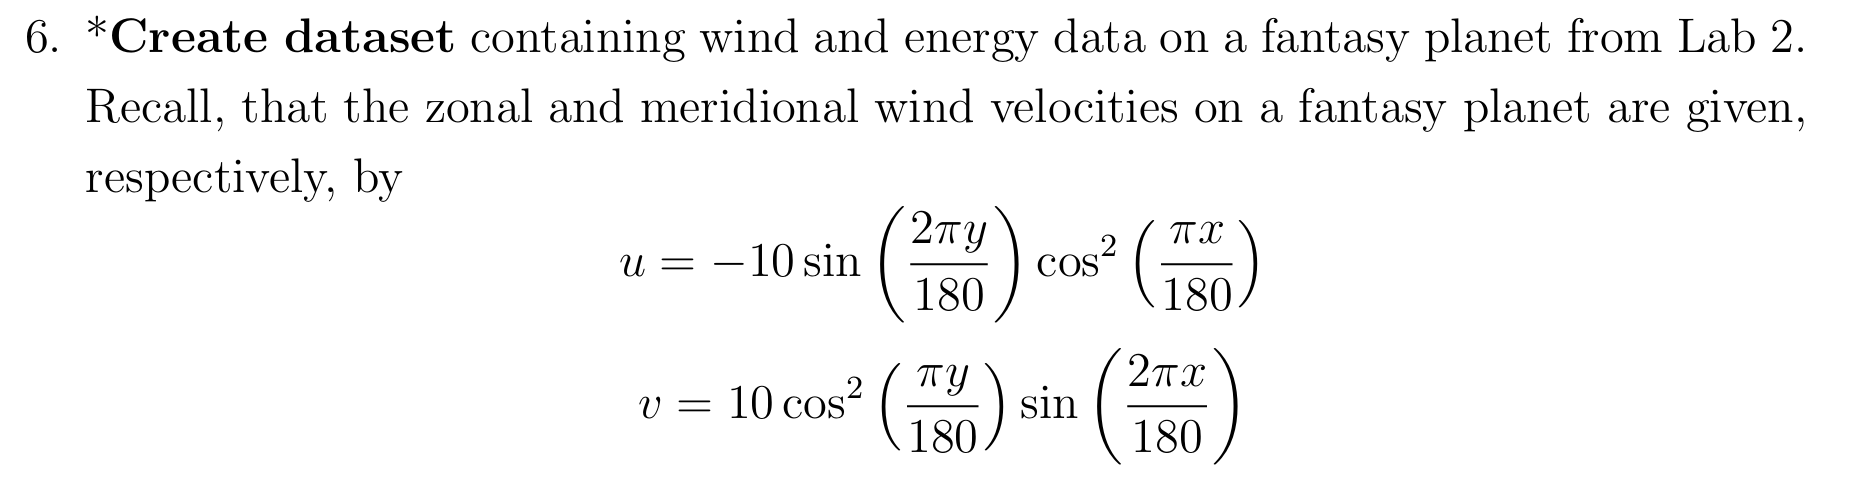
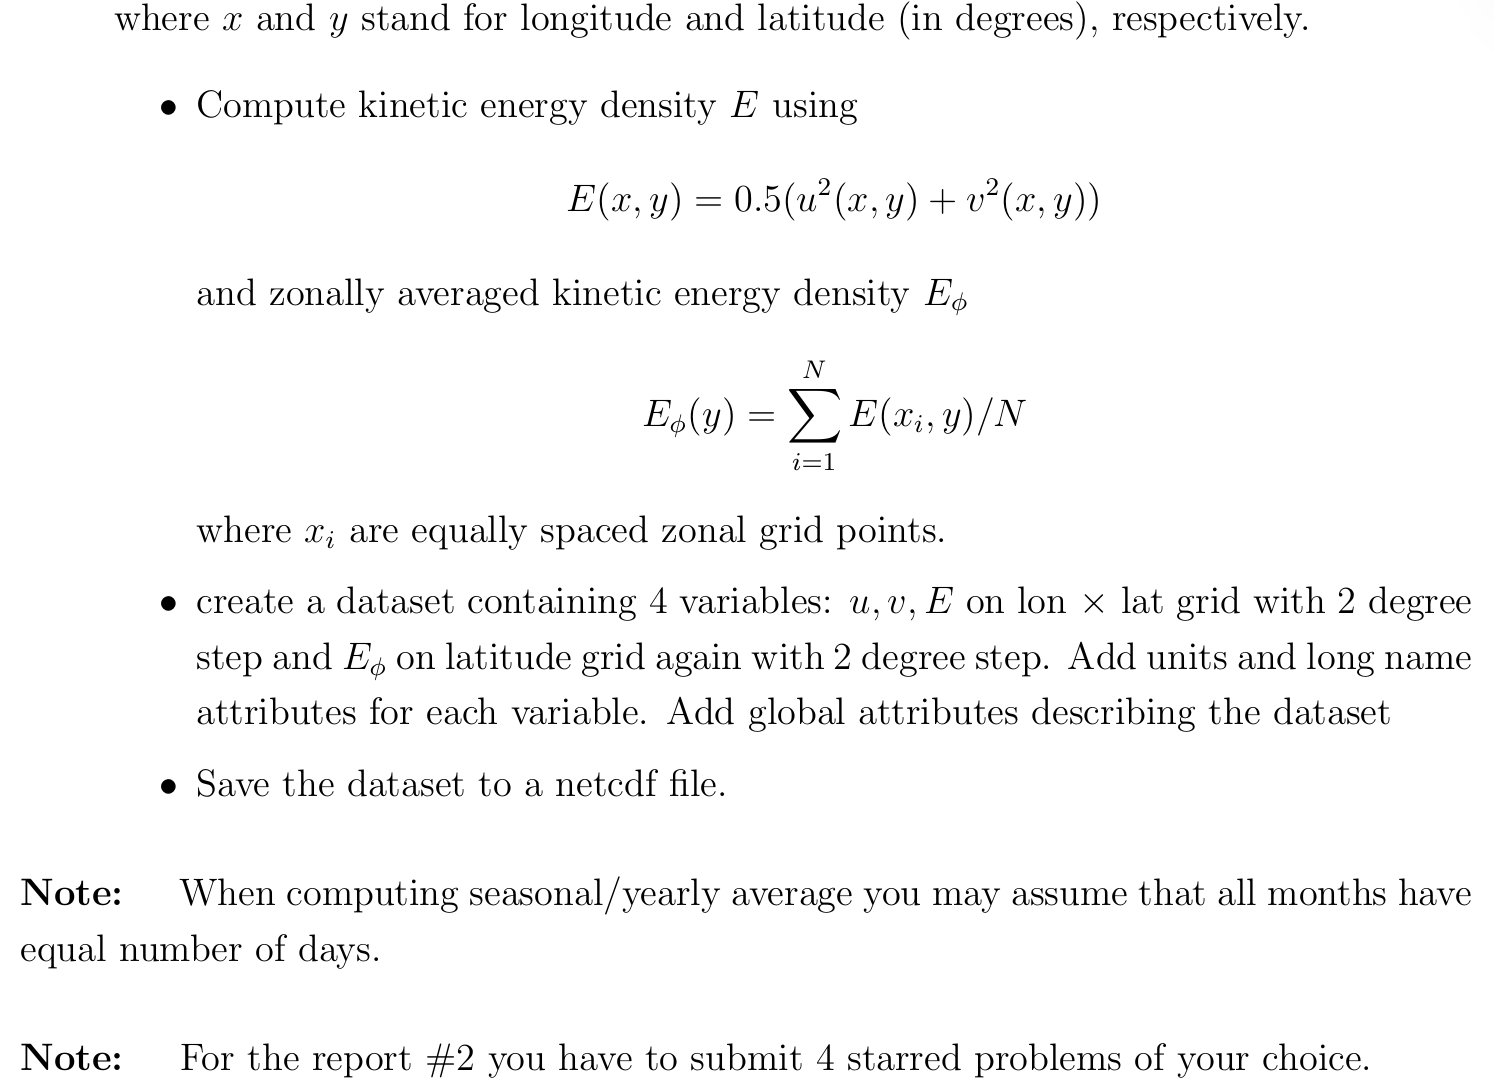